In [1]:
# LEARNING RATE SCHEDULING
# ============================================

import numpy as np
import matplotlib.pyplot as plt

In [5]:

# 1. Step Decay
# --------------------------------------------
epochs = 100
initial_lr = 0.1
drop_rate = 0.5
drop_every = 20

step_lr = []

for epoch in range(epochs):
    lr = initial_lr * (
        drop_rate ** (epoch // drop_every)
    )
    step_lr.append(lr)


# --------------------------------------------
# 2. Cosine Annealing
# --------------------------------------------

cosine_lr = []

for epoch in range(epochs):
    lr = 0.5 * initial_lr * (
        1 + np.cos(np.pi * epoch / epochs)
    )
    cosine_lr.append(lr)


# --------------------------------------------
# 3. Warmup
# --------------------------------------------

warmup_epochs = 20
warmup_lr = []

for epoch in range(epochs):

    if epoch < warmup_epochs:
        lr = initial_lr * (epoch + 1) / warmup_epochs
    else:
        lr = initial_lr

    warmup_lr.append(lr)


# --------------------------------------------
# 4. Cyclical Learning Rate
# --------------------------------------------

min_lr = 0.001
max_lr = 0.1
cycle_length = 20

cyclical_lr = []

for epoch in range(epochs):

    cycle_position = epoch % cycle_length

    if cycle_position < cycle_length / 2:

        lr = min_lr + (
            max_lr - min_lr
        ) * (
            cycle_position / (cycle_length / 2)
        )

    else:

        lr = max_lr - (
            max_lr - min_lr
        ) * (
            (cycle_position - cycle_length / 2)
            / (cycle_length / 2)
        )

    cyclical_lr.append(lr)


# --------------------------------------------


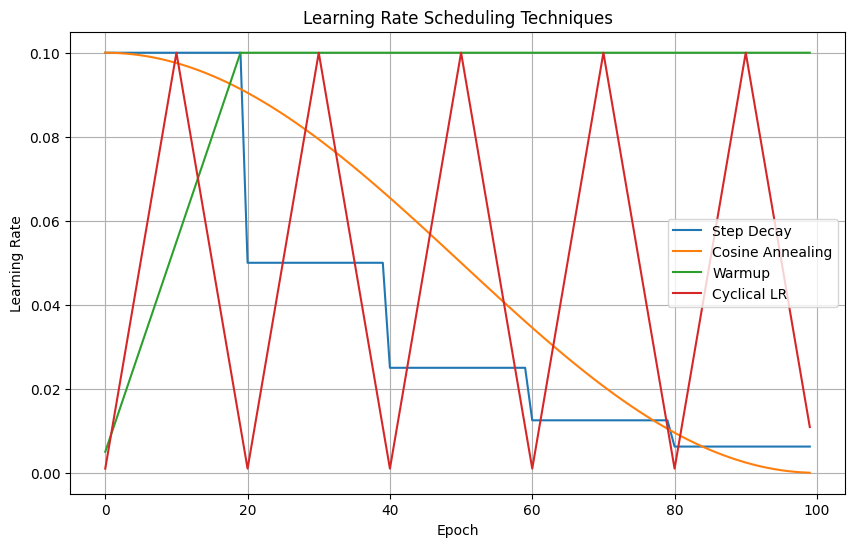

In [6]:
# 5. Plot Schedules
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(step_lr, label="Step Decay")
plt.plot(cosine_lr, label="Cosine Annealing")
plt.plot(warmup_lr, label="Warmup")
plt.plot(cyclical_lr, label="Cyclical LR")

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Scheduling Techniques")

plt.legend()
plt.grid()

plt.show()